In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

import datetime as dt

Importing Data that has been cleared with outliers

In [2]:
df_data = pd.read_csv("RFM_Base.csv")

In [3]:
df_data

,customer_unique_id,order_id,order_date,total_payment
0,3b9a0d6e823e479d97f3642fcc157c3e,7920e7d2f91a12543837febe80d5503a,2018-05-08,88.90
1,0def27ca2bd8b3fd71eb871041c0ece4,3d1a669c8ccacd61bf065e1537d5cad4,2018-06-04,206.69
2,6724236615afbc343645dacfa693fae0,016726239765c18f66826453f39c64e3,2017-06-14,265.77
3,b9094a80af5d0e072d9ca833ce36c90e,96eb9d1d1588412109dae29e68f86e86,2018-05-25,89.55
4,29368e4aa7a6adbb540f40b3074cdd66,c1dbcb501480db95626caa68680696d4,2018-08-21,37.47
...,...,...,...,...
87280,b51e5231c8ece4e6f463f2add2e07f60,6cbc65eb4b9f5320a527cafaf73b7ea1,2018-08-23,34.58
87281,cf717ffae55d20f545be20358a44f698,8d585a78c58bc6ee2c28323cfd8ce6c7,2017-09-24,121.09
87282,d714959800e10629872c11353cbb1913,95811675a89b66659996da5285a021db,2018-08-09,131.97
87283,63305950fe640d20773bdb40c16f7e62,e63bc1942e2cd8ad08839b0032149b58,2017-08-14,203.30


In [4]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87285 entries, 0 to 87284
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  87285 non-null  object 
 1   order_id            87285 non-null  object 
 2   order_date          87285 non-null  object 
 3   total_payment       87285 non-null  float64
dtypes: float64(1), object(3)
memory usage: 2.7+ MB


In [5]:
df_data.describe()

,total_payment
count,87285.000000
mean,111.225127
std,67.103917
min,9.590000
25%,58.090000
50%,95.340000
75%,150.980000
max,553.260000


In [6]:
len(df_data[df_data.duplicated()])

0

Converting to Pandas datetime

In [7]:
time_columns=['order_date']

In [8]:
df_data[time_columns]= df_data[time_columns].apply(pd.to_datetime)

In [9]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87285 entries, 0 to 87284
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_unique_id  87285 non-null  object        
 1   order_id            87285 non-null  object        
 2   order_date          87285 non-null  datetime64[ns]
 3   total_payment       87285 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 2.7+ MB


Getting the latest day to count for Recency

In [10]:
present_day = df_data['order_date'].max() + dt.timedelta(days=1)
present_day

Timestamp('2018-08-30 00:00:00')

In [11]:
print("Latest time in dataset: ", df_data['order_date'].max())

Latest time in dataset:  2018-08-29 00:00:00


Starting getting the attributes for Recency

In [12]:
recency_df = pd.DataFrame(df_data.groupby(by='customer_unique_id', as_index=False)['order_date'].max())
recency_df

,customer_unique_id,order_date
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07
2,0000f46a3911fa3c0805444483337064,2017-03-10
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14
...,...,...
84556,fffbf87b7a1a6fa8b03f081c5f51a201,2017-12-27
84557,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10
84558,ffff371b4d645b6ecea244b27531430a,2017-02-07
84559,ffff5962728ec6157033ef9805bacc48,2018-05-02


In [13]:
recency_df['Recency'] = recency_df['order_date'].apply(lambda x: (present_day - x).days)
recency_df

,customer_unique_id,order_date,Recency
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10,112
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07,115
2,0000f46a3911fa3c0805444483337064,2017-03-10,538
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12,322
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14,289
...,...,...,...
84556,fffbf87b7a1a6fa8b03f081c5f51a201,2017-12-27,246
84557,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10,263
84558,ffff371b4d645b6ecea244b27531430a,2017-02-07,569
84559,ffff5962728ec6157033ef9805bacc48,2018-05-02,120


Frequency attribute

In [14]:
frequency_df = pd.DataFrame(df_data.groupby(['customer_unique_id']).agg({'order_id': 'nunique'}).reset_index())
frequency_df.rename(columns={'order_id': 'Frequency'}, inplace=True)
frequency_df

,customer_unique_id,Frequency
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1
...,...,...
84556,fffbf87b7a1a6fa8b03f081c5f51a201,1
84557,fffea47cd6d3cc0a88bd621562a9d061,1
84558,ffff371b4d645b6ecea244b27531430a,1
84559,ffff5962728ec6157033ef9805bacc48,1


Monetary attribute

In [15]:
monetary_df = pd.DataFrame(df_data.groupby(by='customer_unique_id', as_index=False)['total_payment'].sum())
monetary_df.rename(columns={'total_payment': 'Monetary'}, inplace=True)
monetary_df.head()

,customer_unique_id,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19
2,0000f46a3911fa3c0805444483337064,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89


Now, lets merge them all together

In [16]:
RF_df = recency_df.merge(frequency_df, on='customer_unique_id')
RFM_df = RF_df.merge(monetary_df, on='customer_unique_id').drop(columns='order_date')
RFM_df.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,538,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,322,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,289,1,196.89


In [17]:
RFM_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,84561.0,238.139592,152.266602,1.00,115.00,220.0,346.00,696.00
Frequency,84561.0,1.032213,0.204614,1.00,1.00,1.0,1.00,15.00
Monetary,84561.0,114.808070,72.209008,9.59,59.09,97.8,155.37,1122.72


In [18]:
RFM_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84561 entries, 0 to 84560
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  84561 non-null  object 
 1   Recency             84561 non-null  int64  
 2   Frequency           84561 non-null  int64  
 3   Monetary            84561 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 2.6+ MB


Plot them to see the distribution

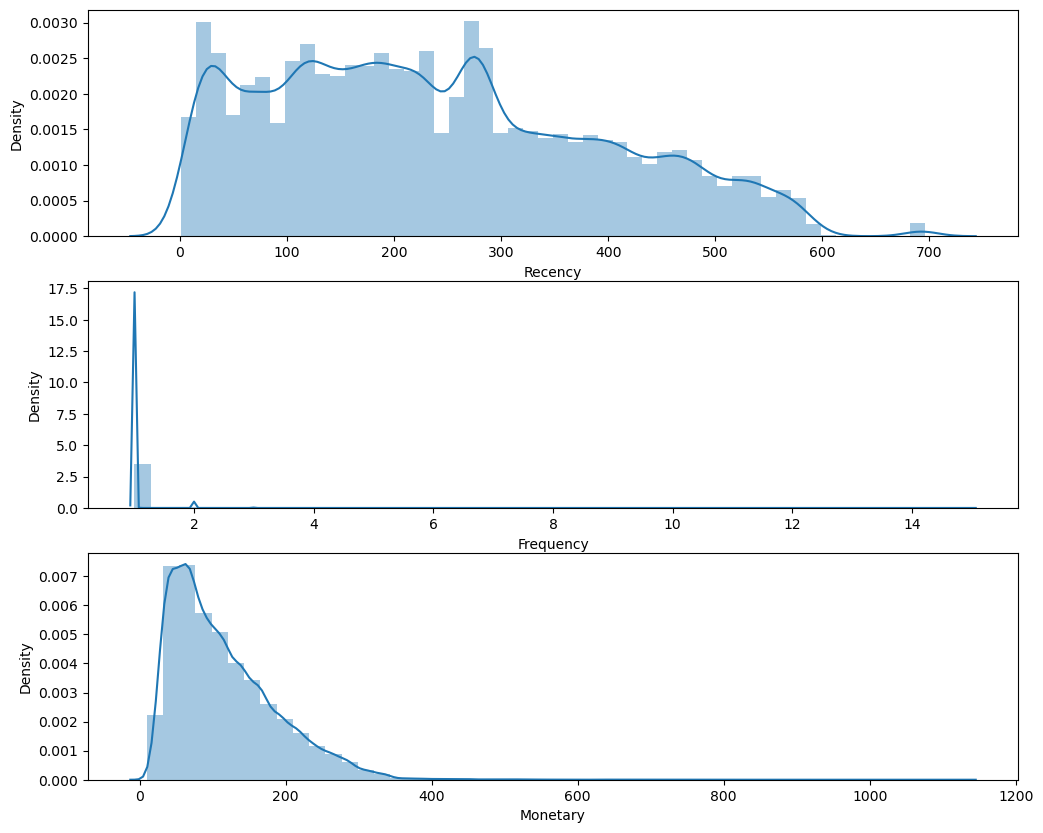

In [19]:
plt.figure(figsize=(12,10))
plt.subplot(3, 1, 1); sns.distplot(RFM_df['Recency'])
plt.subplot(3, 1, 2); sns.distplot(RFM_df['Frequency'])
plt.subplot(3, 1, 3); sns.distplot(RFM_df['Monetary'])
plt.show()

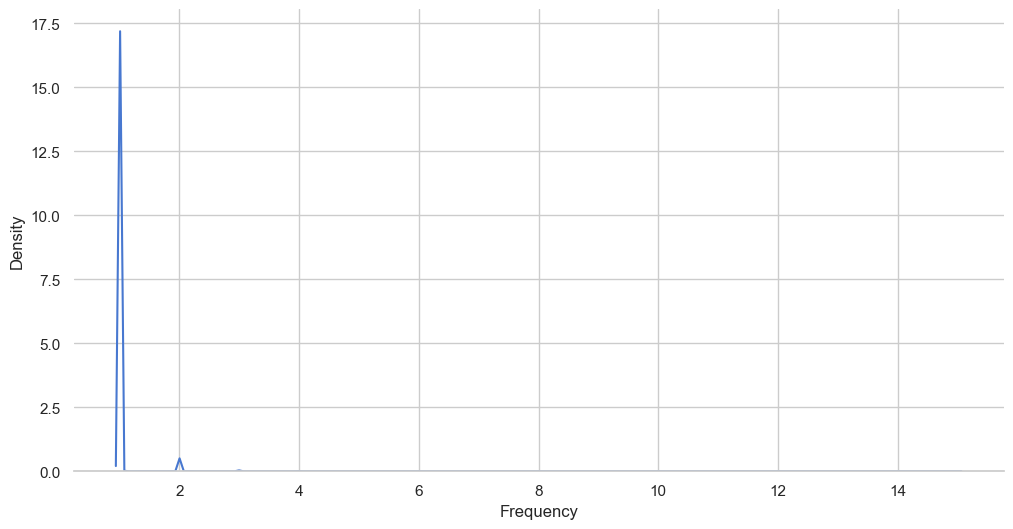

In [20]:
sns.set(palette='muted', color_codes=True, style='whitegrid')
fig, ax = plt.subplots(figsize=(12, 6))
sns.despine(left=True)
sns.distplot(RFM_df['Frequency'], hist=False)
plt.show()

We check the outlier, since we have been cleared with outlier, you can find the outliers detech on 
dbt/mart folder !!!

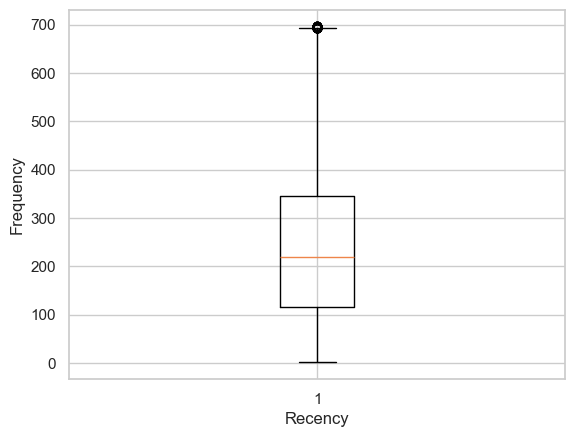

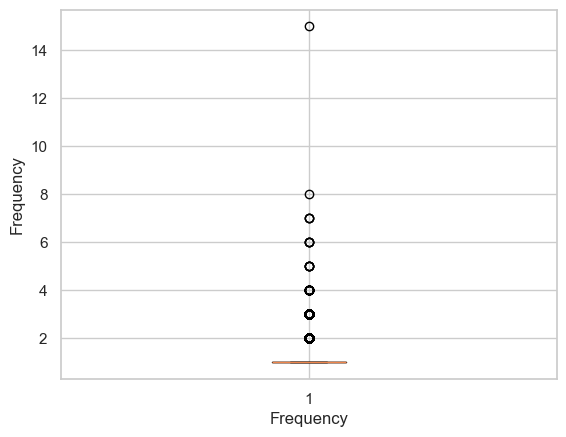

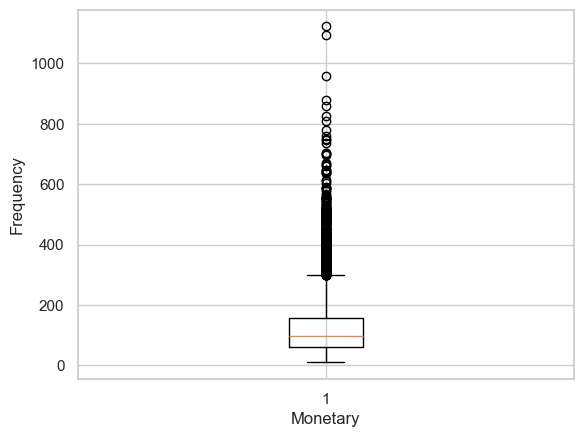

In [21]:
for i in ["Recency", "Frequency", "Monetary"]:
    plt.figure()
    plt.tight_layout()
    plt.gca().set(xlabel= i, ylabel='Frequency')
    plt.boxplot(RFM_df[i])

Customer Segmentation begins, now we segment them with the RFM Score

In [22]:
RFM_df2 = RFM_df.copy()
RFM_df2 = RFM_df2.set_index('customer_unique_id')
RFM_df2

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
0000f46a3911fa3c0805444483337064,538,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,322,1,43.62
0004aac84e0df4da2b147fca70cf8255,289,1,196.89
...,...,...,...
fffbf87b7a1a6fa8b03f081c5f51a201,246,1,167.32
fffea47cd6d3cc0a88bd621562a9d061,263,1,84.58
ffff371b4d645b6ecea244b27531430a,569,1,112.46


Start get the labels for RFM

In [23]:
RFM_df2["Recency_score"]  = pd.qcut(RFM_df2['Recency'], 5, labels=[5, 4, 3, 2, 1])
RFM_df2["Frequency_score"]= pd.qcut(RFM_df2['Frequency'].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
RFM_df2["Monetary_score"] = pd.qcut(RFM_df2['Monetary'], 5, labels=[1, 2, 3, 4, 5])
RFM_df2

,Recency,Frequency,Monetary,Recency_score,Frequency_score,Monetary_score
customer_unique_id,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1
0000f46a3911fa3c0805444483337064,538,1,86.22,1,1,3
0000f6ccb0745a6a4b88665a16c9f078,322,1,43.62,2,1,1
0004aac84e0df4da2b147fca70cf8255,289,1,196.89,2,1,5
...,...,...,...,...,...,...
fffbf87b7a1a6fa8b03f081c5f51a201,246,1,167.32,3,5,4
fffea47cd6d3cc0a88bd621562a9d061,263,1,84.58,3,5,3
ffff371b4d645b6ecea244b27531430a,569,1,112.46,1,5,3


In [24]:
RFM_df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84561 entries, 0000366f3b9a7992bf8c76cfdf3221e2 to ffffd2657e2aad2907e67c3e9daecbeb
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Recency          84561 non-null  int64   
 1   Frequency        84561 non-null  int64   
 2   Monetary         84561 non-null  float64 
 3   Recency_score    84561 non-null  category
 4   Frequency_score  84561 non-null  category
 5   Monetary_score   84561 non-null  category
dtypes: category(3), float64(1), int64(2)
memory usage: 2.8+ MB


Concatenate them together for RFM Score

In [25]:
RFM_df2['RFM_Score'] = RFM_df2.Recency_score.astype(str)+ RFM_df2.Frequency_score.astype(str) + RFM_df2.Monetary_score.astype(str)
RFM_df2

,Recency,Frequency,Monetary,Recency_score,Frequency_score,Monetary_score,RFM_Score
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411
0000f46a3911fa3c0805444483337064,538,1,86.22,1,1,3,113
0000f6ccb0745a6a4b88665a16c9f078,322,1,43.62,2,1,1,211
0004aac84e0df4da2b147fca70cf8255,289,1,196.89,2,1,5,215
...,...,...,...,...,...,...,...
fffbf87b7a1a6fa8b03f081c5f51a201,246,1,167.32,3,5,4,354
fffea47cd6d3cc0a88bd621562a9d061,263,1,84.58,3,5,3,353
ffff371b4d645b6ecea244b27531430a,569,1,112.46,1,5,3,153


Use the link below for more information on the score we use to segment the customer !!!!

https://documentation.bloomreach.com/engagement/docs/rfm-segmentation

In [26]:
seg_map= {
    r'111|112|121|131|141|151': 'Lost customers',
    r'332|322|233|232|223|222|132|123|122|212|211': 'Hibernating customers', 
    r'155|154|144|214|215|115|114|113': 'Cannot Lose Them',
    r'255|254|245|244|253|252|243|242|235|234|225|224|153|152|145|143|142|135|134|133|125|124': 'At Risk',
    r'331|321|312|221|213|231|241|251': 'About To Sleep',
    r'535|534|443|434|343|334|325|324': 'Need Attention',
    r'525|524|523|522|521|515|514|513|425|424|413|414|415|315|314|313': 'Promising',
    r'512|511|422|421|412|411|311': 'New Customers',
    r'553|551|552|541|542|533|532|531|452|451|442|441|431|453|433|432|423|353|352|351|342|341|333|323': 'Potential Loyalist',
    r'543|444|435|355|354|345|344|335': 'Loyal',
    r'555|554|544|545|454|455|445': 'Champions'
}

In [27]:
RFM_df2['Segment'] = RFM_df2.Recency_score.astype(str)+ RFM_df2.Frequency_score.astype(str) + RFM_df2.Monetary_score.astype(str)
RFM_df2['Segment'] = RFM_df2['Segment'].replace(seg_map, regex=True)
RFM_df2

,Recency,Frequency,Monetary,Recency_score,Frequency_score,Monetary_score,RFM_Score,Segment
customer_unique_id,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414,Promising
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411,New Customers
0000f46a3911fa3c0805444483337064,538,1,86.22,1,1,3,113,Cannot Lose Them
0000f6ccb0745a6a4b88665a16c9f078,322,1,43.62,2,1,1,211,Hibernating customers
0004aac84e0df4da2b147fca70cf8255,289,1,196.89,2,1,5,215,Cannot Lose Them
...,...,...,...,...,...,...,...,...
fffbf87b7a1a6fa8b03f081c5f51a201,246,1,167.32,3,5,4,354,Loyal
fffea47cd6d3cc0a88bd621562a9d061,263,1,84.58,3,5,3,353,Potential Loyalist
ffff371b4d645b6ecea244b27531430a,569,1,112.46,1,5,3,153,At Risk


In [28]:
RFM_df2['Segment'].nunique()

11

In [29]:
RFM_df2['Segment'].unique()

array(['Promising', 'New Customers', 'Cannot Lose Them',
       'Hibernating customers', 'Lost customers', 'About To Sleep',
       'Loyal', 'Champions', 'At Risk', 'Potential Loyalist',
       'Need Attention'], dtype=object)

In [30]:
RFM_Stats = RFM_df2[['Segment', 'Recency', 'Frequency', 'Monetary']].groupby('Segment').agg(['mean', 'median', 'min','max', 'count'])
RFM_Stats

Recency                         Frequency         \
                             mean median  min  max  count      mean median   
Segment                                                                      
About To Sleep         277.604519  278.0  179  382   5267  1.000380    1.0   
At Risk                385.141159  367.0  269  696  14558  1.042451    1.0   
Cannot Lose Them       435.636773  438.0  269  696   5330  1.060600    1.0   
Champions               85.715266   82.0    2  178   5247  1.197827    1.0   
Hibernating customers  342.317202  325.0  179  696   7749  1.000000    1.0   
Lost customers         475.563730  469.0  383  696   4268  1.002109    1.0   
Loyal                  179.116055  194.0    1  268   5506  1.089175    1.0   
Need Attention         156.786604  178.0    2  268   5300  1.000000    1.0   
New Customers          124.205508  128.0    1  268   4720  1.000000    1.0   
Potential Loyalist     130.778081  131.0    1  268  15749  1.015430    1.0   
Promising              105.937609   92.0    1  268  10867  1.000000    1.0   

                                        Monetary                            \
                      min max  count        mean   median     min      max   
Segment                                                                      
About To Sleep          1   2   5267   49.104084   42.780   10.07   117.16   
At Risk                 1   6  14558  144.074419  130.885   52.59   749.31   
Cannot Lose Them        1   4   5330  168.778054  154.095   79.93   586.37   
Champions               1  15   5247  200.861235  184.030  117.26  1122.72   
Hibernating customers   1   1   7749   72.132159   69.450   11.63   117.16   
Lost customers          1   3   4268   42.905230   41.640   12.28    79.71   
Loyal                   1   8   5506  182.312290  173.240   79.95   959.01   
Need Attention          1   1   5300  149.255849  138.715   79.92   421.69   
New Customers           1   1   4720   49.714532   48.210    9.59    79.72   
Potential Loyalist      1   3  15749   67.306053   65.670   10.89   117.16   
Promising               1   1  10867  144.208887  136.310   14.06   388.88   

                              
                       count  
Segment                       
About To Sleep          5267  
At Risk                14558  
Cannot Lose Them        5330  
Champions               5247  
Hibernating customers   7749  
Lost customers          4268  
Loyal                   5506  
Need Attention          5300  
New Customers           4720  
Potential Loyalist     15749  
Promising              10867

In [31]:
RFM_Stats['Ratio']= (100*RFM_Stats['Monetary']["count"]/RFM_Stats['Monetary']["count"].sum()).round(2)
RFM_Stats

Recency                         Frequency         \
                             mean median  min  max  count      mean median   
Segment                                                                      
About To Sleep         277.604519  278.0  179  382   5267  1.000380    1.0   
At Risk                385.141159  367.0  269  696  14558  1.042451    1.0   
Cannot Lose Them       435.636773  438.0  269  696   5330  1.060600    1.0   
Champions               85.715266   82.0    2  178   5247  1.197827    1.0   
Hibernating customers  342.317202  325.0  179  696   7749  1.000000    1.0   
Lost customers         475.563730  469.0  383  696   4268  1.002109    1.0   
Loyal                  179.116055  194.0    1  268   5506  1.089175    1.0   
Need Attention         156.786604  178.0    2  268   5300  1.000000    1.0   
New Customers          124.205508  128.0    1  268   4720  1.000000    1.0   
Potential Loyalist     130.778081  131.0    1  268  15749  1.015430    1.0   
Promising              105.937609   92.0    1  268  10867  1.000000    1.0   

                                        Monetary                            \
                      min max  count        mean   median     min      max   
Segment                                                                      
About To Sleep          1   2   5267   49.104084   42.780   10.07   117.16   
At Risk                 1   6  14558  144.074419  130.885   52.59   749.31   
Cannot Lose Them        1   4   5330  168.778054  154.095   79.93   586.37   
Champions               1  15   5247  200.861235  184.030  117.26  1122.72   
Hibernating customers   1   1   7749   72.132159   69.450   11.63   117.16   
Lost customers          1   3   4268   42.905230   41.640   12.28    79.71   
Loyal                   1   8   5506  182.312290  173.240   79.95   959.01   
Need Attention          1   1   5300  149.255849  138.715   79.92   421.69   
New Customers           1   1   4720   49.714532   48.210    9.59    79.72   
Potential Loyalist      1   3  15749   67.306053   65.670   10.89   117.16   
Promising               1   1  10867  144.208887  136.310   14.06   388.88   

                              Ratio  
                       count         
Segment                              
About To Sleep          5267   6.23  
At Risk                14558  17.22  
Cannot Lose Them        5330   6.30  
Champions               5247   6.20  
Hibernating customers   7749   9.16  
Lost customers          4268   5.05  
Loyal                   5506   6.51  
Need Attention          5300   6.27  
New Customers           4720   5.58  
Potential Loyalist     15749  18.62  
Promising              10867  12.85

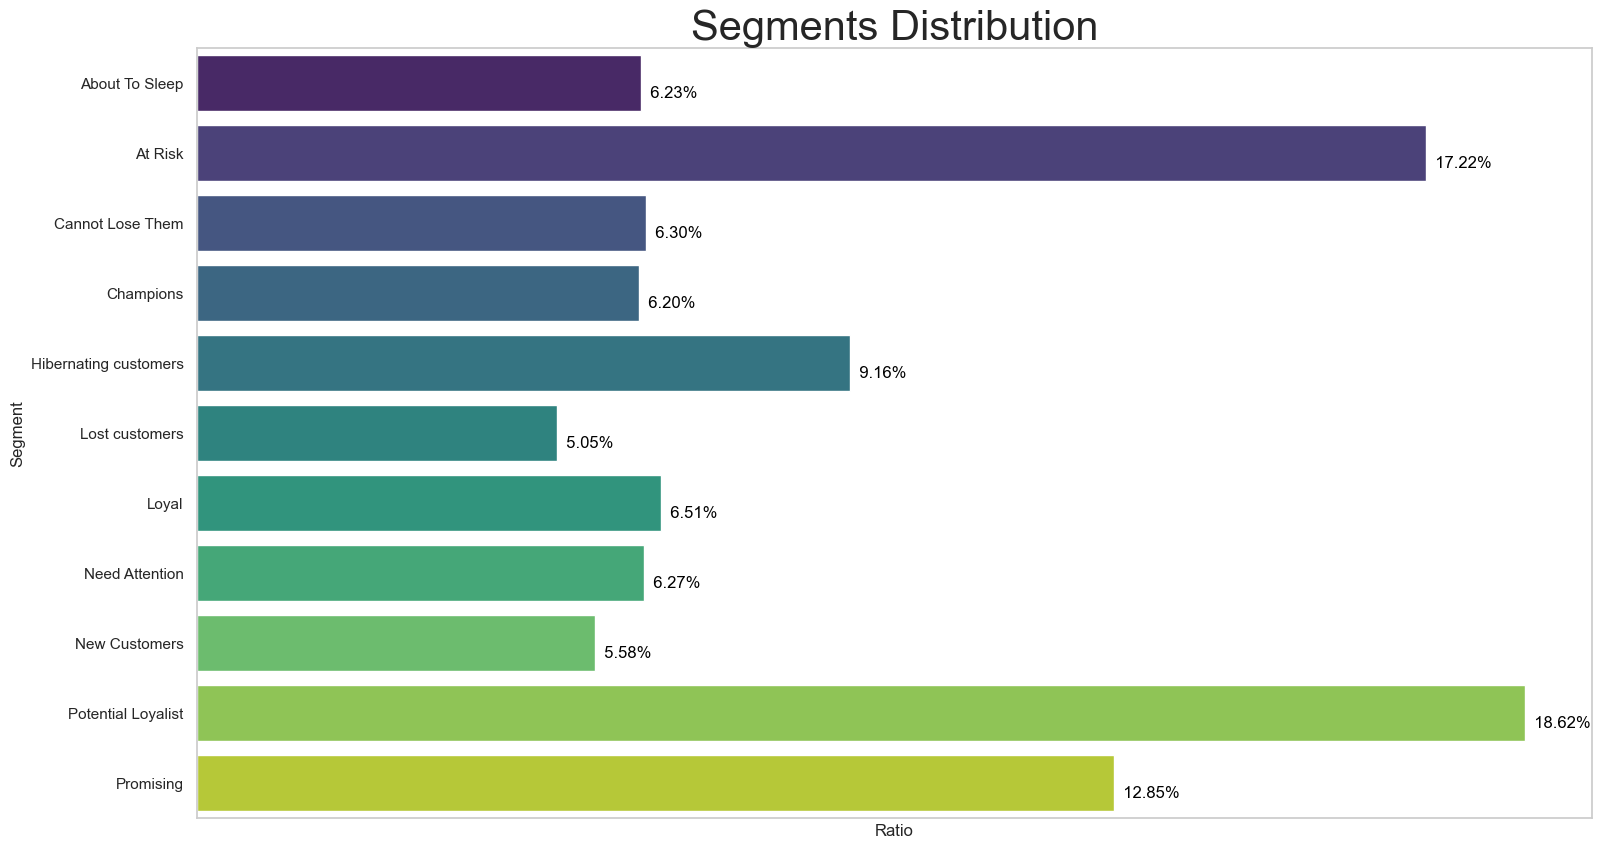

In [32]:
plt.figure(figsize=(18,10))
plt.title('Segments Distribution', fontsize=30)
per_seg = sns.barplot(x=RFM_Stats['Ratio'], y = RFM_Stats.index, palette='viridis')
for i, v in enumerate(RFM_Stats['Ratio']):
    per_seg.text(v, i+.20,"  {:.2f}".format(v)+"%", color='black', ha='left')
per_seg.set(xticks=[])
plt.show()

In [33]:
!pip install squarify
import squarify

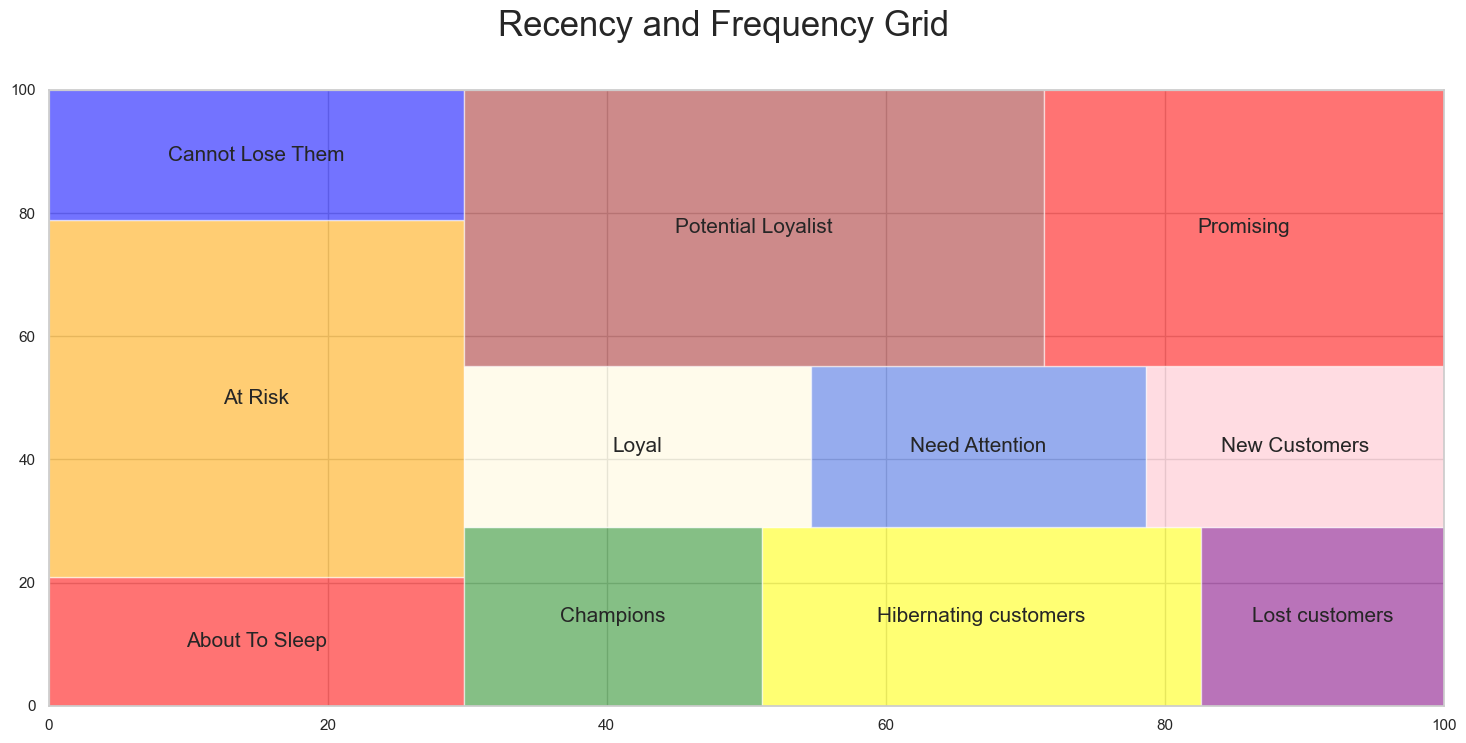

In [34]:
plt.figure(figsize=(18,8))
plt.rc('font', size=15)
squarify.plot(sizes=RFM_Stats['Recency']['count'], label=RFM_Stats.index,
              color=["red","orange","blue", "forestgreen", "yellow", "purple", "cornsilk","royalblue", "pink", "brown"],
              alpha=.55)
plt.suptitle('Recency and Frequency Grid', fontsize=25)
plt.show()

Customer Segment with K-Means

In [35]:
RFM_df3 = RFM_df2.drop(['Recency_score', 'Frequency_score', 'Monetary_score', 'RFM_Score', 'Segment'], axis=1)
RFM_df3

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
0000f46a3911fa3c0805444483337064,538,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,322,1,43.62
0004aac84e0df4da2b147fca70cf8255,289,1,196.89
...,...,...,...
fffbf87b7a1a6fa8b03f081c5f51a201,246,1,167.32
fffea47cd6d3cc0a88bd621562a9d061,263,1,84.58
ffff371b4d645b6ecea244b27531430a,569,1,112.46


Check skew data with scipy

In [36]:
from scipy import stats
def skewed_check(df, column):
    skew = stats.skew(df[column])
    skewtest = stats.skewtest(df[column])
    plt.title(column)
    sns.distplot(df[column])
    plt.show()
    print(skew, skewtest, column)
    return

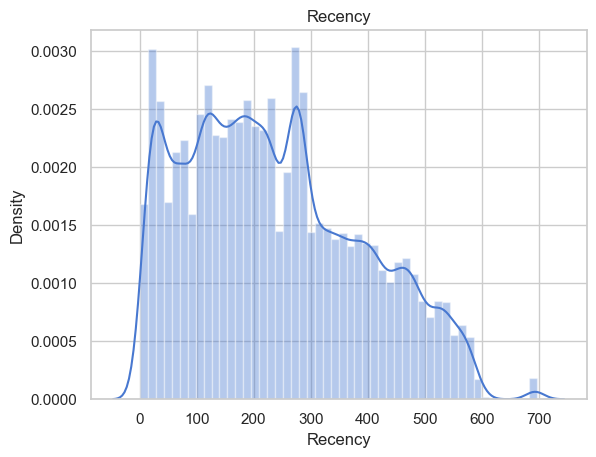

0.44316544933080143 SkewtestResult(statistic=50.325021529531035, pvalue=0.0) Recency


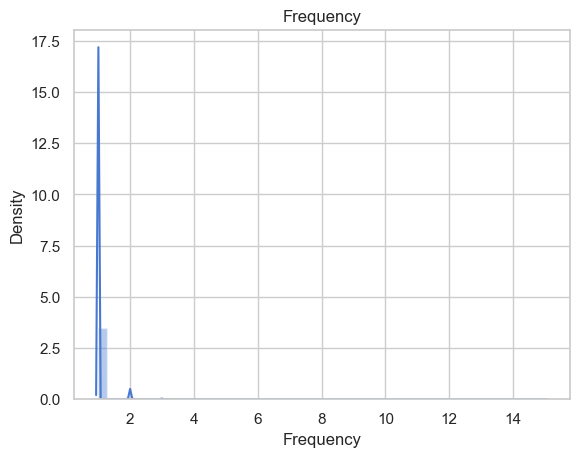

11.525790287426167 SkewtestResult(statistic=323.97595865874763, pvalue=0.0) Frequency


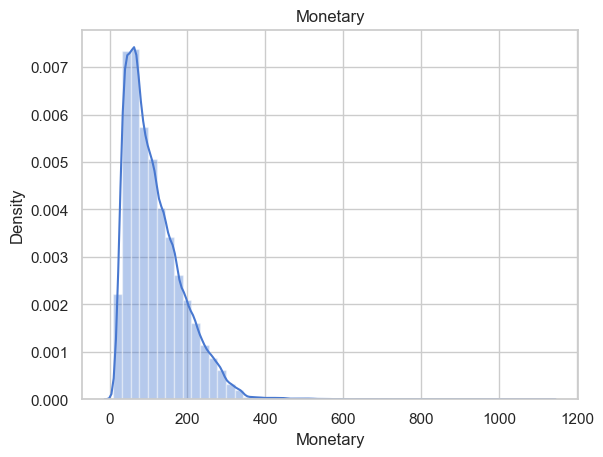

1.3484398407742368 SkewtestResult(statistic=123.69713071725309, pvalue=0.0) Monetary


In [37]:
for col in RFM_df3.columns:
    skewed_check(RFM_df3, col)

The skewness value greater than 1 or less than -1 indicates a highly skewed distribution.
The value between 0.5 and 1 or -0.5 and -1 is moderately skewed.
The value between -0.5 and 0.5 indicates that the distribution is fairly symmetrical.
https://docs.oracle.com/cd/E57185_01/CBREG/ch03s02s03s01.html#:~:text=A%20skewness%20value%20greater%20than,the%20distribution%20is%20fairly%20symmetrical

We need to apply log transform for the Frequency and Monetary columns as they are very skewed.

In [38]:
RFM_log = RFM_df3.copy()
for i in RFM_log.columns[1:]:
    RFM_log[i] = np.log10(RFM_log[i])
RFM_log

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,0.0,2.151982
0000b849f77a49e4a4ce2b2a4ca5be3f,115,0.0,1.434409
0000f46a3911fa3c0805444483337064,538,0.0,1.935608
0000f6ccb0745a6a4b88665a16c9f078,322,0.0,1.639686
0004aac84e0df4da2b147fca70cf8255,289,0.0,2.294224
...,...,...,...
fffbf87b7a1a6fa8b03f081c5f51a201,246,0.0,2.223548
fffea47cd6d3cc0a88bd621562a9d061,263,0.0,1.927268
ffff371b4d645b6ecea244b27531430a,569,0.0,2.050998


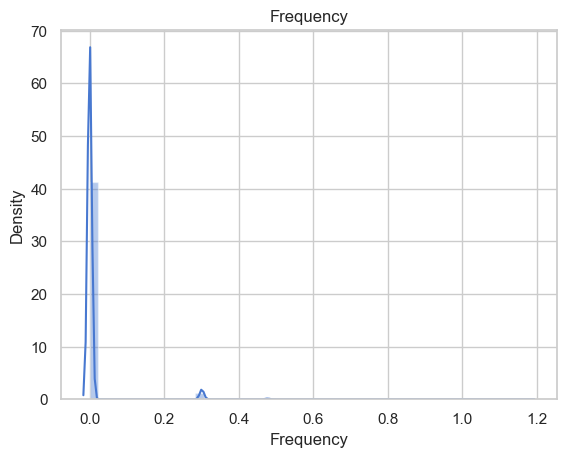

6.176687269565007 SkewtestResult(statistic=263.7958126002644, pvalue=0.0) Frequency


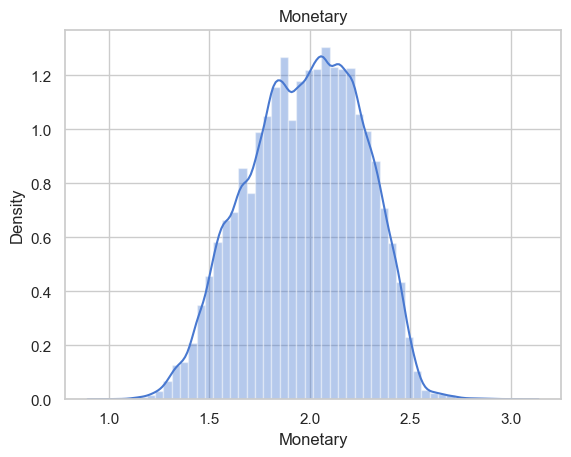

-0.17247543563244655 SkewtestResult(statistic=-20.328146359705148, pvalue=7.248960472077575e-92) Monetary


In [39]:
for col in RFM_log.columns[1:]:
    skewed_check(RFM_log, col)

Standardize using the StandardScaler

In [40]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

In [41]:
RFM_log_scaled = scaler.fit_transform(RFM_log)
RFM_log_scaled_df = pd.DataFrame(RFM_log_scaled)
RFM_log_scaled_df.columns = ['Recency','Frequency','Monetary']
RFM_log_scaled_df.head()

,Recency,Frequency,Monetary
0,-0.828418,-0.169562,0.633603
1,-0.808715,-0.169562,-1.935417
2,1.969323,-0.169562,-0.141049
3,0.550750,-0.169562,-1.200496
4,0.334024,-0.169562,1.142849


In [42]:
RFM_log_scaled_df.dtypes

Recency      float64
Frequency    float64
Monetary     float64
dtype: object

In [43]:
print("Hello world")

Hello world


Finding K-Clusters using Elbow method

Now, we have different methods on find the best K clusters to segment
- Inertia
- Distortion
- Silhouette
Since the Distortion can be used with the yellowbrick.cluster below, make sure to install the yellowbrick first
Below this is the Inertia and Silhouette Score on finding the best K clusters, we use the sample of 20k users to find the K.

In [56]:
RFM_log_scaled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84561 entries, 0 to 84560
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    84561 non-null  float64
 1   Frequency  84561 non-null  float64
 2   Monetary   84561 non-null  float64
dtypes: float64(3)
memory usage: 1.9 MB


In [45]:
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score

In [65]:
sample_df = RFM_log_scaled_df.sample(n=20000, random_state=42)

In [90]:
inertias = []
sil_scores = []
for i in range(2, 9):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=5, max_iter=300)
    lbs = kmeans.fit_predict(sample_df)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(sample_df, lbs))

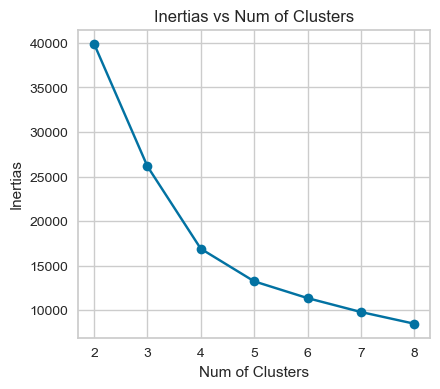

In [91]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(range(2, 9), inertias, marker='o')
plt.title('Inertias vs Num of Clusters')
plt.xlabel('Num of Clusters')
plt.ylabel('Inertias')
plt.show()

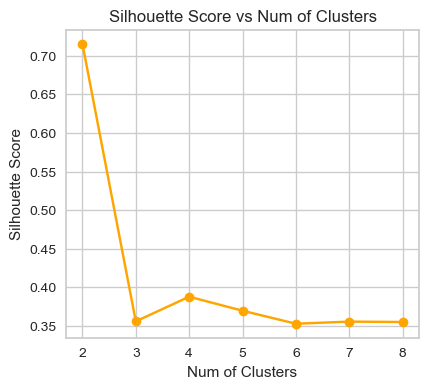

In [92]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,2)
plt.plot(range(2, 9), sil_scores, marker='o', color='orange')
plt.title('Silhouette Score vs Num of Clusters')
plt.xlabel('Num of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [63]:
from yellowbrick.cluster import KElbowVisualizer

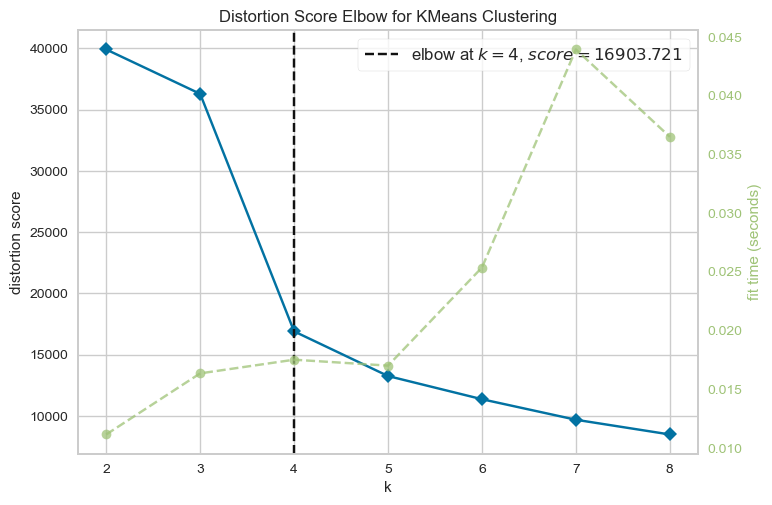

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [68]:
k_means = KMeans()
elbow = KElbowVisualizer(k_means, k=(2,9))
elbow.fit(sample_df)
elbow.show()

The cluster found to be 4 is best 

In [69]:
kmean_true= KMeans(n_clusters=4)
kmean_true.fit(RFM_log_scaled_df)

KMeans(n_clusters=4)

In [71]:
RFM_log_scaled_df['Cluster'] = kmean_true.labels_
RFM_log_scaled_df.head()

,Recency,Frequency,Monetary,Cluster
0,-0.828418,-0.169562,0.633603,1
1,-0.808715,-0.169562,-1.935417,0
2,1.969323,-0.169562,-0.141049,2
3,0.550750,-0.169562,-1.200496,0
4,0.334024,-0.169562,1.142849,1


In [86]:
def rfm_clusters_stat(df):
    df_new = df.groupby(['Cluster']).agg({
            'Recency'  : ['mean', 'min', 'max'],
            'Frequency': ['mean','min', 'max'],
            'Monetary' : ['mean', 'min', 'max', 'count']
        }).round(0)

    return df_new

In [74]:
RFM_df_cluster = RFM_df3.copy()
RFM_df_cluster['Cluster'] = kmean_true.labels_
RFM_df_cluster.head()

,Recency,Frequency,Monetary,Cluster
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,1
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,0
0000f46a3911fa3c0805444483337064,538,1,86.22,2
0000f6ccb0745a6a4b88665a16c9f078,322,1,43.62,0
0004aac84e0df4da2b147fca70cf8255,289,1,196.89,1


In [87]:
rfm_clusters_stat(RFM_df_cluster).style.background_gradient(cmap='YlGnBu')

In [88]:
rfm_clusters_stat(RFM_df_cluster)

Recency           Frequency         Monetary                     
           mean  min  max      mean min max     mean   min     max  count
Cluster                                                                  
0         168.0    1  470       1.0   1   1     52.0  10.0    88.0  26278
1         154.0    1  408       1.0   1   1    162.0  84.0   553.0  32071
2         431.0  265  696       1.0   1   1    109.0  15.0   473.0  23754
3         222.0    2  692       2.0   2  15    229.0  36.0  1123.0   2458

- Cluster 0: Mainly new customer with the Recency is fairly but the Monetary is too low, they seems new and not totally potential in long cycle with business (need to be considered with this Cluster).
- Cluster 1: More spent on the Monetary and less Recency, they seem potential and need to be re-engaged to active again.
- Cluster 2: The Recency too high, they spent fairly well, this Cluster seems to be lost and not easy to re-engaged.
- Cluster 3: The Champions and Loyalist, well spent with fairly Recency, needs to be in special watchout for business.

In [82]:
RFM_Stats = pd.DataFrame(rfm_clusters_stat(RFM_df_cluster))

Text(0.5, 0.98, 'Segments of Customers')

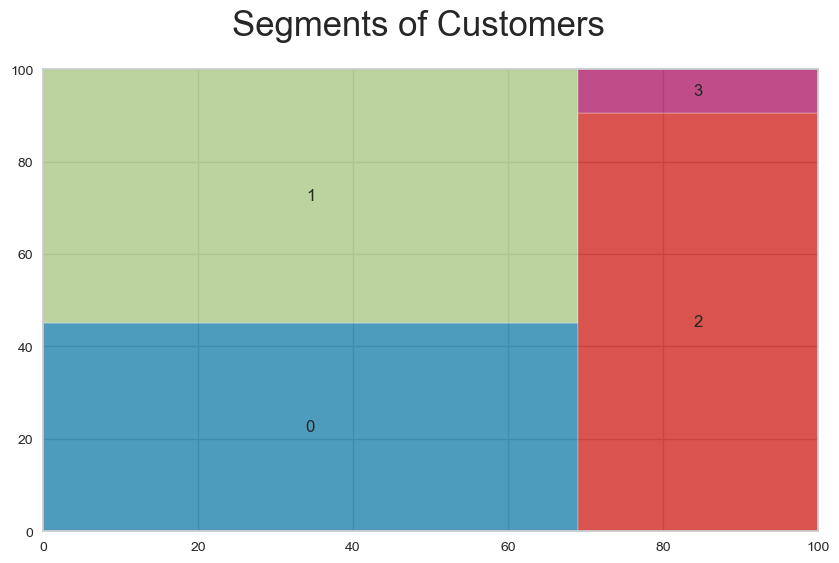

In [84]:
plt.figure(figsize=(10, 6))
squarify.plot(sizes=RFM_Stats["Monetary"]["count"], label=RFM_Stats.index, color=["b","g","r","m","c", "y"], alpha=0.7)
plt.suptitle("Segments of Customers", fontsize=25)